# 🚲 자전거 대여 수요 예측 프로젝트

**목표**
>[Kaggle Bike Sharing Demand](https://www.kaggle.com/competitions/bike-sharing-demand) 데이터를 활용하여 자전거 대여량을 예측하는 머신러닝 모델을 개발하고, <br>개선하는 End-to-End 파이프라인을 구축합니다.

---

## 프로젝트 진행 순서

| 단계 | 내용 |
|------|------|
| **Step 1** | 데이터 읽기 |
| **Step 2** | 전처리 (결측치, 이상치, 타입 변환) |
| **Step 3** | 탐색적 데이터 분석 (EDA) |
| **Step 4** | 베이스라인 모델 개발 |
| **Step 5** | 1차 평가 |
| **Step 6** | 개선 방향 수립 |
| **Step 7** | 1차 개선 (피쳐 엔지니어링 + 모델 변경) |
| **Step 8** | 2차 평가 |
| **Step 9** | 1차 평가와 비교하여 개선 확인 |

---
# Step 1. 데이터 읽기

Kaggle의 Bike Sharing Demand 데이터를 불러옵니다.
- `train.csv`: 학습 데이터 (datetime, 기상정보, 대여 수량 등)
- `test.csv`: 테스트 데이터 (대여 수량이 없음)

In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.2 MB/s eta 0:00:00


In [2]:
!apt-get install -y fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 직접 등록
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 6 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (25.6 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for Korean font display
plt.rcParams['font.family'] = 'NanumGothic'  # NanumGothic 폰트로 설정
plt.rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_log_error, r2_score

plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
# 학습 데이터 로드
train_data = pd.read_csv('train.csv')
print(f"Train 데이터 Shape: {train_data.shape}")
train_data.head()

Train 데이터 Shape: (10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [5]:
# 테스트 데이터 로드
test_data = pd.read_csv('test.csv')
print(f"Test 데이터 Shape: {test_data.shape}")
test_data.head()

Test 데이터 Shape: (6493, 9)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014


### 데이터 컬럼 설명

| 컬럼 | 설명 |
|------|------|
| datetime | 시간 정보 |
| season | 계절 (1:봄, 2:여름, 3:가을, 4:겨울) |
| holiday | 공휴일 여부 (0/1) |
| workingday | 근무일 여부 (0/1) |
| weather | 날씨 (1:맑음 ~ 4:매우 나쁨) |
| temp | 온도 (섭씨) |
| atemp | 체감 온도 (섭씨) |
| humidity | 습도 |
| windspeed | 풍속 |
| casual | 비등록 사용자 대여 수 |
| registered | 등록 사용자 대여 수 |
| count | 총 대여 수 (Target) |

---
# Step 2. 전처리

데이터를 모델에 넣기 전에 필요한 기본적인 전처리를 수행합니다.

## 2-1. 결측치 확인

In [6]:
print("=== Train 결측치 ===")
print(train_data.isnull().sum())
print()
print("=== Test 결측치 ===")
print(test_data.isnull().sum())

=== Train 결측치 ===
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

=== Test 결측치 ===
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
dtype: int64


> 결측치가 없는 깨끗한 데이터임을 확인했습니다.

## 2-2. 데이터 타입 확인 및 변환

범주형 변수(season, holiday, workingday, weather)를 Categorical 타입으로 변환합니다.

In [ ]:
print(train_data.dtypes)
print(train_data.dtypes)

datetime       object
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object
datetime       object
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object


In [ ]:
# 범주형 변수 타입 변환
for col in ['season', 'holiday', 'workingday', 'weather']:
    train_data[col] = pd.Categorical(train_data[col])
    test_data[col] = pd.Categorical(test_data[col])

In [ ]:
print(train_data.dtypes)

datetime        object
season        category
holiday       category
workingday    category
weather       category
temp           float64
atemp          float64
humidity         int64
windspeed      float64
casual           int64
registered       int64
count            int64
dtype: object


## 2-3. 이상치 확인 및 처리

BoxPlot을 통해 수치형 변수의 이상치를 시각적으로 확인합니다.

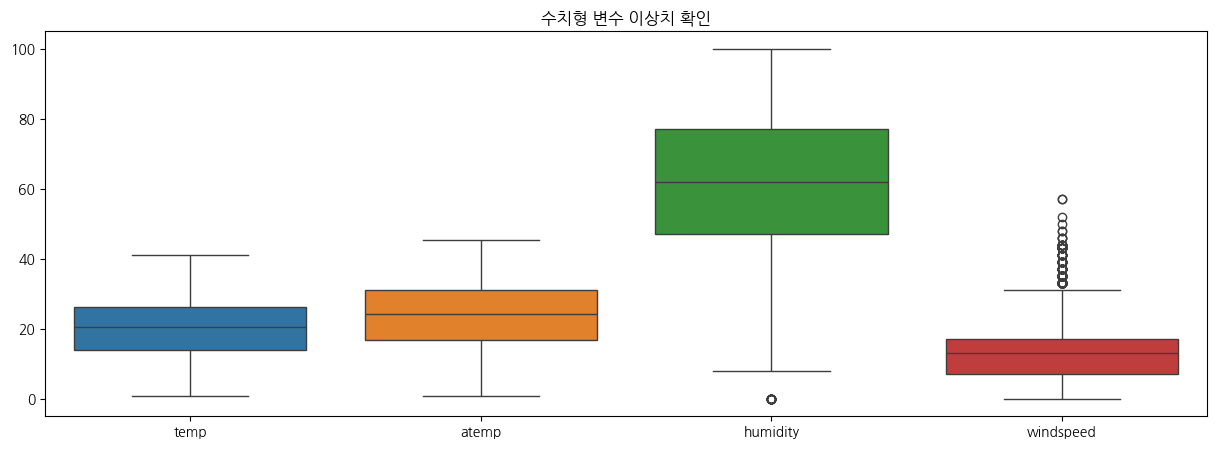

In [ ]:
plt.figure(figsize=(15, 5))
sns.boxplot(train_data.drop(columns=['casual', 'registered', 'count']))
plt.title('수치형 변수 이상치 확인')
plt.show()

IQR(사분위범위) 방식을 사용해 이상치를 제거합니다.
- **습도(humidity)**, **풍속(windspeed)** 이상치 248개 제거

In [ ]:
def IQR(df, column):
    """IQR 방식으로 이상치를 제거하는 함수"""
    q3 = df[column].quantile(0.75)
    q1 = df[column].quantile(0.25)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr
    df = df[(df[column] >= lower) & (df[column] <= upper)]
    return df

print(f"이상치 제거 전: {train_data.shape}")
train_data = IQR(train_data, 'humidity')
train_data = IQR(train_data, 'windspeed')
print(f"이상치 제거 후: {train_data.shape}")

이상치 제거 전: (10886, 12)
이상치 제거 후: (10638, 12)


## 2-4. datetime 컬럼 처리

datetime에서 year, month, day, hour 정보를 추출하여 새로운 피쳐로 만듭니다.

In [7]:
# Train 데이터 datetime 파싱
train_data['datetime'] = pd.to_datetime(train_data['datetime'])
train_data['year'] = train_data['datetime'].dt.year
train_data['month'] = train_data['datetime'].dt.month
train_data['day'] = train_data['datetime'].dt.day
train_data['hour'] = train_data['datetime'].dt.hour

# Test 데이터 datetime 파싱
test_data['datetime'] = pd.to_datetime(test_data['datetime'])
test_data['year'] = test_data['datetime'].dt.year
test_data['month'] = test_data['datetime'].dt.month
test_data['day'] = test_data['datetime'].dt.day
test_data['hour'] = test_data['datetime'].dt.hour

print("Train 컬럼:", list(train_data.columns))
print("Test 컬럼:", list(test_data.columns))

Train 컬럼: ['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count', 'year', 'month', 'day', 'hour']
Test 컬럼: ['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'year', 'month', 'day', 'hour']


---
# Step 3. 탐색적 데이터 분석 (EDA)

데이터의 패턴과 특성을 시각적으로 분석합니다.

## 3-1. 시간대별/월별/연도별 대여량 분석

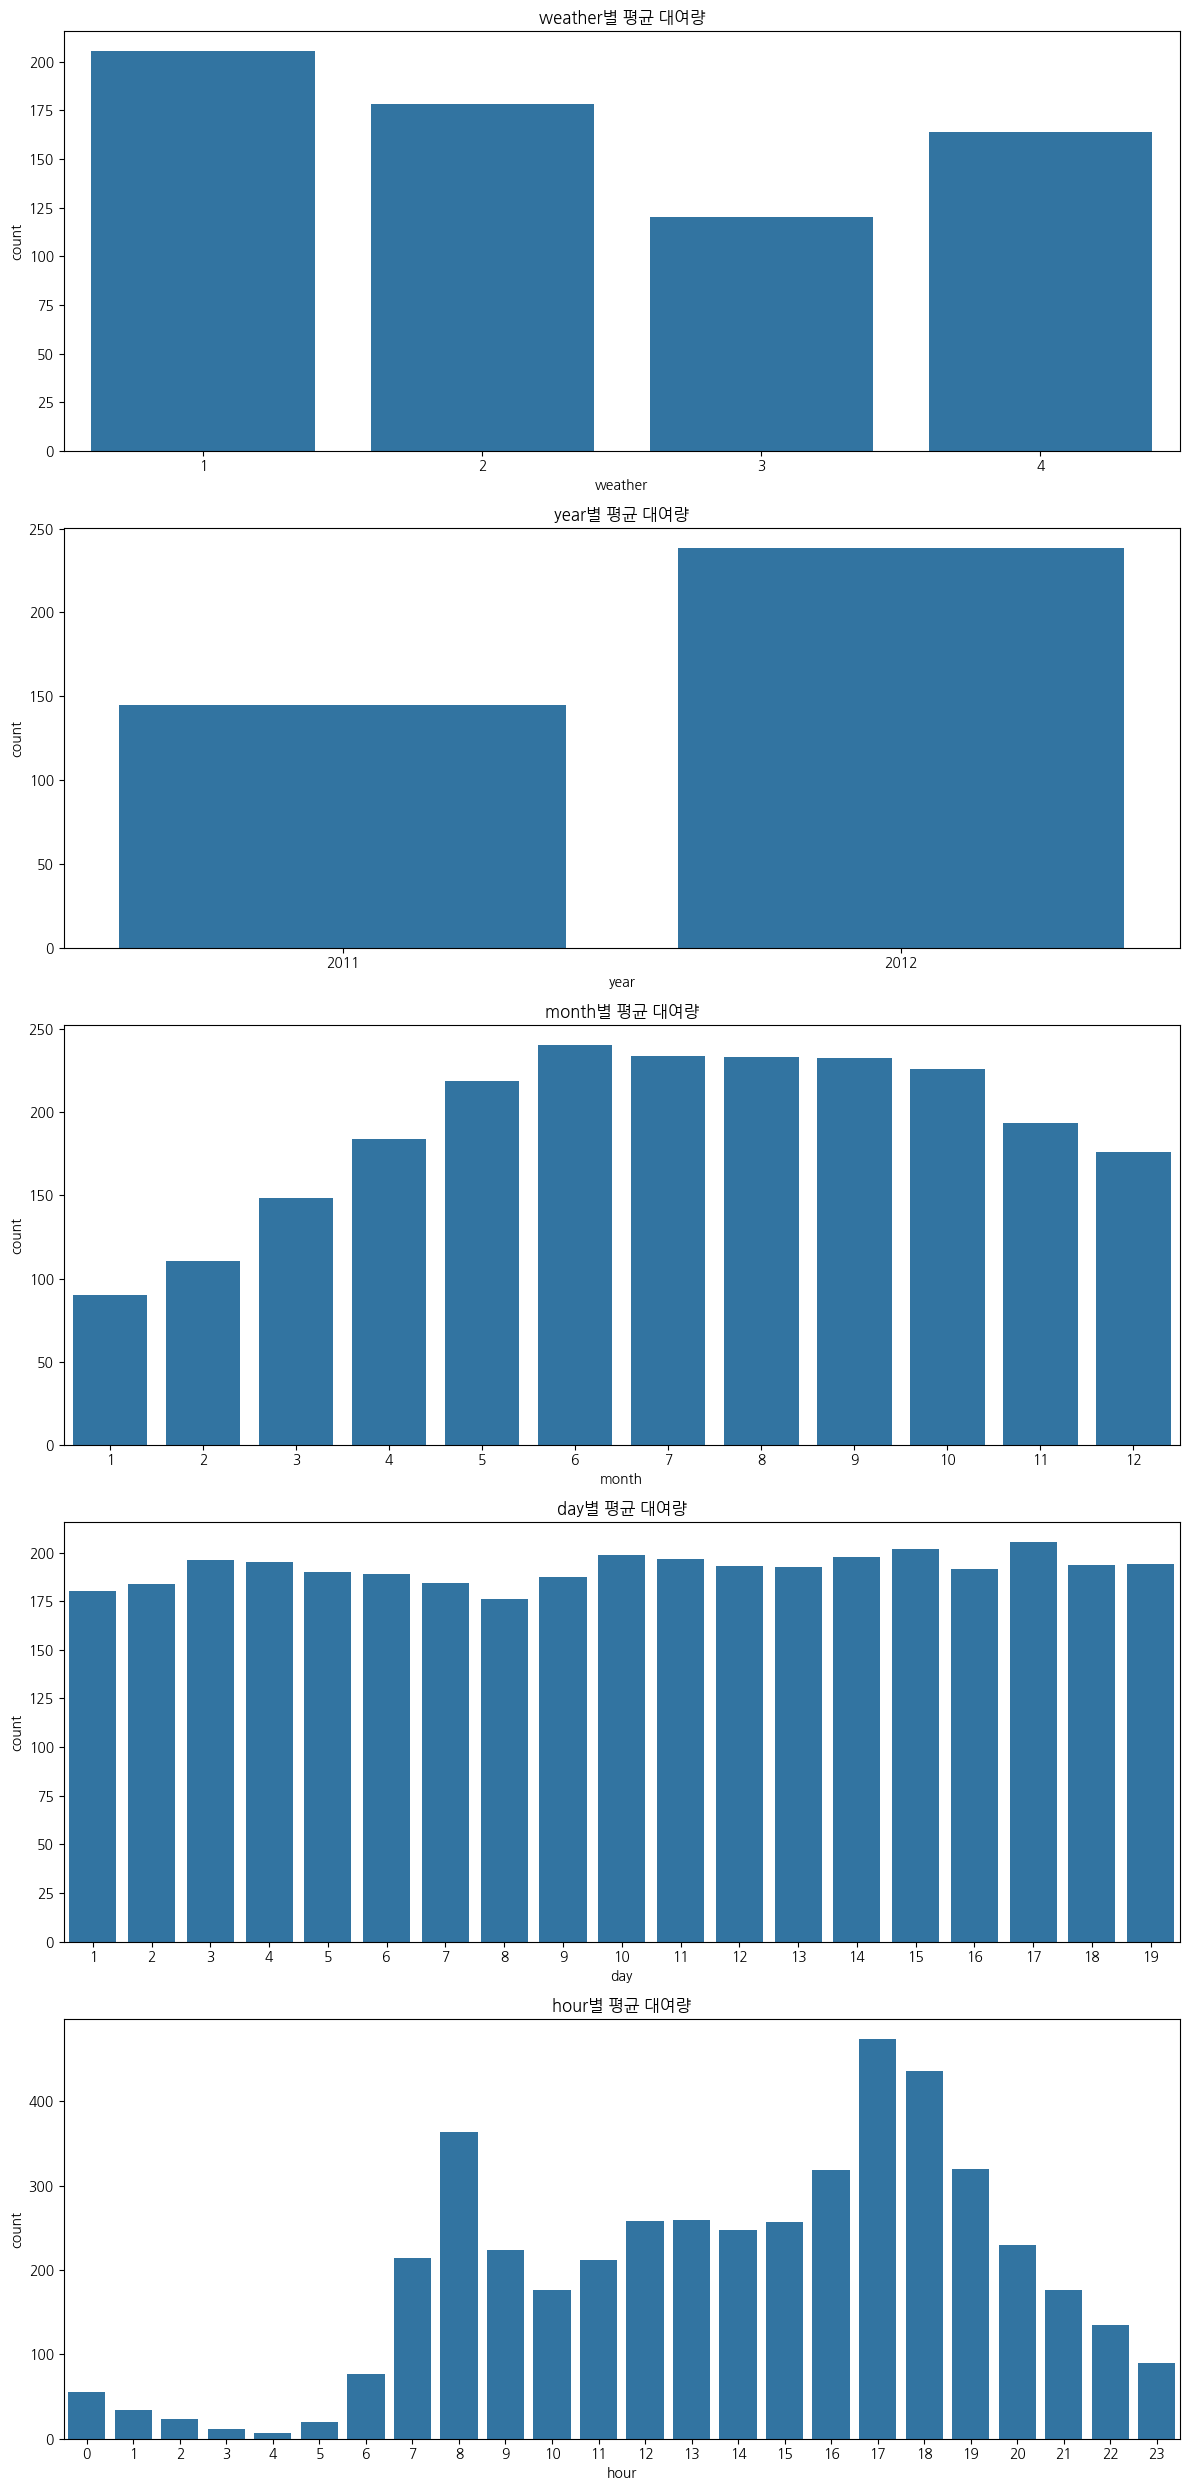

In [ ]:
f_cols = ['weather', 'year', 'month', 'day', 'hour']
plt.figure(figsize=(12, 25))

for idx, val in enumerate(f_cols):
    plt.subplot(len(f_cols), 1, idx + 1)
    sns.barplot(data=train_data, x=val, y='count', errorbar=None)
    plt.title(f'{val}별 평균 대여량')

plt.tight_layout()
plt.show()

**분석 결과**
- **weather**: 날씨가 좋을수록(1에 가까울수록) 대여량이 많음
- **year**: 2012년이 2011년보다 대여량 증가
- **month**: 5~10월 (따뜻한 계절)에 대여량 높음
- **hour**: 출근(8시), 퇴근(17-18시) 시간대에 대여량 최고
- **day**: 1-19일이 학습, 20-31일이 테스트 데이터로 구성

## 3-2. 근무일/공휴일별 대여량 분석

#### 컬럼 의미 해석
*   workingday (근무일 여부)
    *   0 주말이나 공휴일 (출근하지 않는 날)
    *   1 주중 (월~금)이며 공휴일이 아닌 날 (출근하는 날)
*   holiday (공휴일 여부)
    *   0 공휴일이 아님
    *   1 공휴일 (주말과는 별개의 개념)

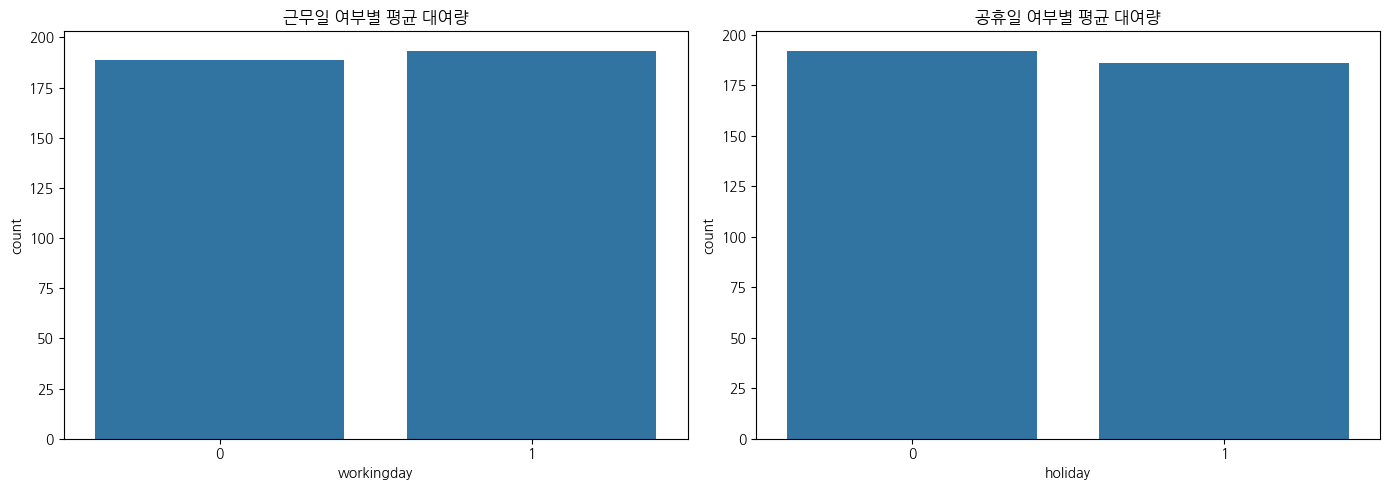

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=train_data, x='workingday', y='count', errorbar=None, ax=axes[0])
axes[0].set_title('근무일 여부별 평균 대여량')

sns.barplot(data=train_data, x='holiday', y='count', errorbar=None, ax=axes[1])
axes[1].set_title('공휴일 여부별 평균 대여량')

plt.tight_layout()
plt.show()

#### 📊 분석 결과

**workingday**
- 근무일별 평균 대여량 차이가 크지 않습니다.
- 자전거가 출퇴근 용도(workingday=1)뿐만 아니라 레저 및 여가 용도(workingday=0)로도 활발히 이용되고 있음을 시사

**holiday**
- 공휴일이 아닐 때 약간 더 대여량이 늘어나는 패턴을 보임

## 3-3. 상관관계 분석

In [ ]:
# registered, casual 제외한 상관관계 분석
train_corr = train_data.drop(columns=['registered', 'casual'])
corr_result = train_corr.select_dtypes(include=[np.number]).corr()['count'].abs().sort_values(ascending=False)
print("=== count와의 상관관계 (절대값 기준) ===")
print(corr_result)

=== count와의 상관관계 (절대값 기준) ===
count        1.000000
hour         0.404701
temp         0.390926
atemp        0.386236
humidity     0.333542
year         0.257846
month        0.162575
windspeed    0.115145
day          0.021824
Name: count, dtype: float64


> - **hour, temp, atemp**가 count와 가장 높은 상관관계
> - **temp와 atemp**는 서로 매우 높은 상관관계 → 둘 중 하나 제거 가능
> - **windspeed**는 상관관계가 매우 낮음

## 3-4. 기온/습도/풍속과 대여량 관계

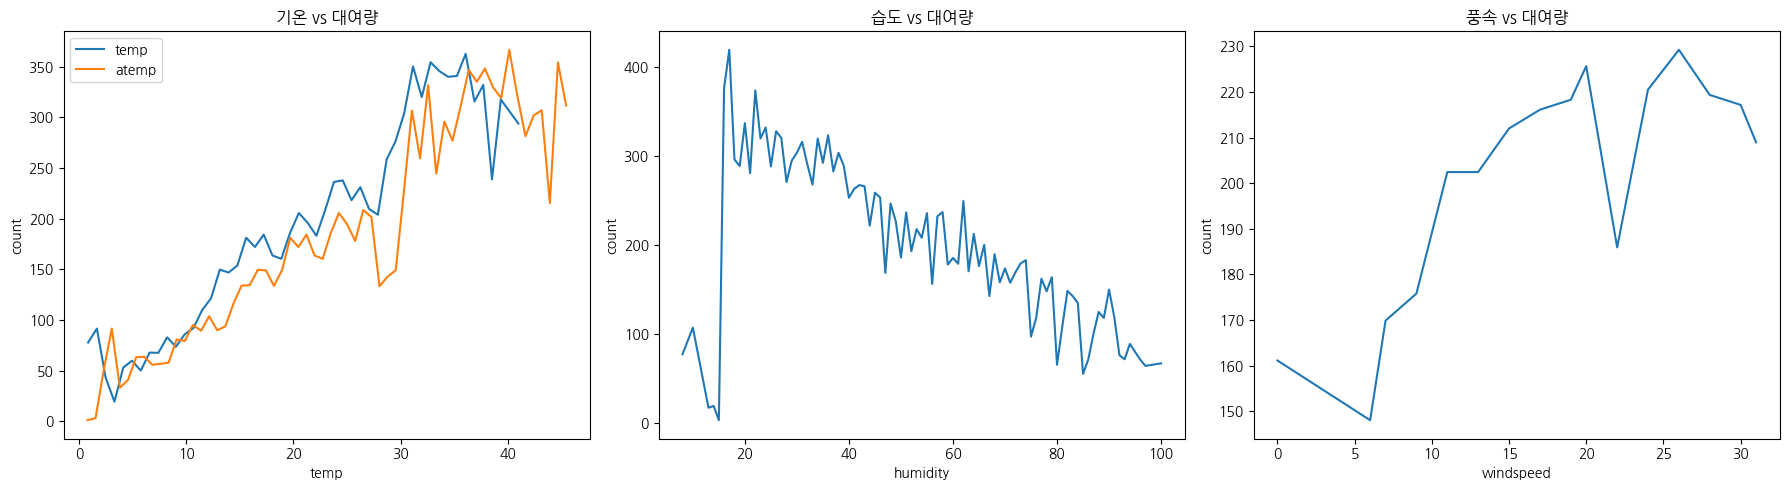

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(data=train_data, x='temp', y='count', errorbar=None, ax=axes[0], label='temp')
sns.lineplot(data=train_data, x='atemp', y='count', errorbar=None, ax=axes[0], label='atemp')
axes[0].set_title('기온 vs 대여량')
axes[0].legend()

sns.lineplot(data=train_data, x='humidity', y='count', errorbar=None, ax=axes[1])
axes[1].set_title('습도 vs 대여량')

sns.lineplot(data=train_data, x='windspeed', y='count', errorbar=None, ax=axes[2])
axes[2].set_title('풍속 vs 대여량')

plt.tight_layout()
plt.show()

#### 📊 분석 결과
- **기온**: 기온이 높을수록 대여량 증가 (양의 상관관계)
- **습도**: 습도가 낮을수록 대여량 증가 (약한 음의 상관관계)
- **풍속**: 풍속과 대여량은 뚜렷한 상관관계가 없음

---
# Step 4. 베이스라인 모델 개발

기본적인 전처리만 적용한 상태에서 **RandomForest** 모델을 학습시켜 베이스라인 성능을 확인합니다.

- 피쳐 엔지니어링 없이, datetime에서 추출한 기본 변수만 사용
- 평가 지표: **RMSLE** (Root Mean Squared Logarithmic Error)

### 💡 RMSLE (Root Mean Squared Logarithmic Error)를 사용하는 이유

이 프로젝트에서 RMSE가 아닌 **RMSLE**를 사용하는 주요 이유는 다음과 같습니다.

1.  **아웃라이어(Outlier)에 강건함**:
    *   자전거 대여량은 특정 시간(출퇴근 등)에 폭발적으로 증가할 수 있습니다. RMSLE는 로그를 취하기 때문에 큰 수치가 들어와도 오차의 영향력이 RMSE보다 상대적으로 적어 이상치에 덜 민감합니다.

2.  **상대적 오차(Relative Error) 측정**:
    *   예를 들어, 실제 대여량이 10대인데 20대로 예측한 것과, 1,000대인데 1,010대로 예측한 경우 RMSE는 동일하게 10의 오차를 보이지만, RMSLE는 전자의 오차를 훨씬 크게 측정합니다. 즉, 값의 규모가 달라도 비율적으로 얼마나 틀렸는지를 중요하게 봅니다.

3.  **Under-prediction(과소평가)에 대한 페널티**:
    *   RMSLE는 예측값이 실제값보다 작을 때(과소평가) 더 큰 페널티를 부여하는 성질이 있습니다. 자전거 대여 서비스 입장에서는 자전거가 남는 것보다 모자란 상황이 더 치명적일 수 있으므로, 이러한 특성이 비즈니스 로직에 적합합니다.

In [9]:
# 피쳐/타겟 분리
"""
'datetime'은 시간 정보를 변수로 분해해 사용했으므로 원본은 제외
'casual', 'registered'는 전체 대여량(count)을 구성하는 값(=target leak)으로 제외
'count'는 예측해야 할 타겟 변수이므로 제외
"""
X_baseline = train_data.drop(columns=['datetime', 'casual', 'registered', 'count'])
y_baseline = train_data['count']

# 학습/검증 분리
X_train_b, X_val_b, y_train_b, y_val_b = train_test_split(
    X_baseline, y_baseline, test_size=0.2, random_state=10
)

print(f"학습 데이터: {X_train_b.shape}")
print(f"검증 데이터: {X_val_b.shape}")
print(f"사용 피쳐: {list(X_baseline.columns)}")

학습 데이터: (8708, 12)
검증 데이터: (2178, 12)
사용 피쳐: ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'year', 'month', 'day', 'hour']


In [10]:
# RandomForest 베이스라인 모델 학습
rf_baseline = RandomForestRegressor(n_estimators=20, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_b, y_train_b)

# 예측 (음수 방지)
pred_val_b = np.maximum(0, rf_baseline.predict(X_val_b))

---
# Step 5. 1차 평가 (베이스라인)

베이스라인 모델의 Train/Test 성능과 오차 크기를 확인합니다.

In [11]:
train_score_b = round(rf_baseline.score(X_train_b, y_train_b), 4)
test_score_b = round(r2_score(y_val_b, pred_val_b), 4)
rmsle_b = round(np.sqrt(mean_squared_log_error(y_val_b, pred_val_b)), 4)

print("[ 1차 평가 - 베이스라인 RandomForest ]")
print(f"  Train Score  : {train_score_b}")
print(f"  Test Score   : {test_score_b}")
print(f"  RMSLE        : {rmsle_b}")

[ 1차 평가 - 베이스라인 RandomForest ]
  Train Score  : 0.9901
  Test Score   : 0.9395
  RMSLE        : 0.3632


---
# Step 6. 개선 방향 수립

1차 평가 결과를 분석하여 모델 성능을 개선할 방향을 수립합니다.

## 문제 진단
- Train Score는 높지만 Test Score가 낮음 → **과적합(Overfitting)** 가능성
- 기본 피쳐만으로는 대여 패턴을 충분히 설명하지 못함

## 개선 방향

| 개선 항목 | 상세 내용 |
|----------|----------|
| **피쳐 엔지니어링** | 요일(day_of_week), 시간대별 평균 대여량 등 파생 변수 생성 |
| **변수 선택** | 상관관계가 높은 중복 변수(atemp, month) 및 불필요 변수(day) 제거 |
| **타겟 변환** | count의 양의 편향(skewness)을 log 변환으로 해소 |
| **모델 변경** | CatBoost 등 Gradient Boosting 계열 모델 적용 |

---
# Step 7. 1차 개선

위에서 수립한 개선 방향에 따라 모델을 개선합니다.

## 7-1. 피쳐 엔지니어링

### (1) day_of_week 변수 추가
요일 정보를 추가합니다. (0:월요일 ~ 6:일요일)

In [12]:
train_data['day_of_week'] = train_data['datetime'].dt.dayofweek
test_data['day_of_week'] = test_data['datetime'].dt.dayofweek
print("day_of_week 분포:")
print(train_data['day_of_week'].value_counts().sort_index())

day_of_week 분포:
day_of_week
0    1551
1    1539
2    1551
3    1553
4    1529
5    1584
6    1579
Name: count, dtype: int64


### (2) 시간대별 평균 대여량 피쳐
각 시간대(hour)별 평균 대여량을 파생 피쳐로 추가합니다.

In [13]:
groupby_df = train_data.groupby('hour')['count'].mean().reset_index()
groupby_df.columns = ['hour', 'mean_count_by_hour']
print(groupby_df.head(20))

train_data = train_data.merge(groupby_df, on='hour', how='left')
test_data = test_data.merge(groupby_df, on='hour', how='left')

    hour  mean_count_by_hour
0      0           55.138462
1      1           33.859031
2      2           22.899554
3      3           11.757506
4      4            6.407240
5      5           19.767699
6      6           76.259341
7      7          213.116484
8      8          362.769231
9      9          221.780220
10    10          175.092308
11    11          210.674725
12    12          256.508772
13    13          257.787281
14    14          243.442982
15    15          254.298246
16    16          316.372807
17    17          468.765351
18    18          430.859649
19    19          315.278509


### (3) daytype 변수 생성
근무일/쉬는날/연휴 전날을 구분하는 변수를 생성합니다.
- 0: 근무일
- 1: 쉬는 날 하루 전 (금요일, 연휴 전날)
- 2: 쉬는 날 (주말, 공휴일)

In [14]:
# Train daytype 생성
holiday_ = train_data[train_data['holiday'] == 1]
holiday_list = holiday_['datetime'].astype(str).str.split(' ').str[0].drop_duplicates().values
holiday_before = (pd.to_datetime(holiday_list) - pd.Timedelta(days=1)).strftime('%Y-%m-%d').tolist()
holiday_before = pd.to_datetime(holiday_before)

train_data['daytype'] = train_data['datetime'].dt.normalize().isin(holiday_before).astype(int)
train_data.loc[train_data['day_of_week'] == 4, 'daytype'] = 1
train_data.loc[train_data['holiday'] == 1, 'daytype'] = 2

# Test daytype 생성
holiday_ = test_data[test_data['holiday'] == 1]
test_holiday_list = holiday_['datetime'].astype(str).str.split(' ').str[0].drop_duplicates().values
holiday_before = (pd.to_datetime(test_holiday_list) - pd.Timedelta(days=1)).strftime('%Y-%m-%d').tolist()
holiday_before = pd.to_datetime(holiday_before)

test_data['daytype'] = test_data['datetime'].dt.normalize().isin(holiday_before).astype(int)
test_data.loc[test_data['day_of_week'] == 4, 'daytype'] = 1
test_data.loc[test_data['holiday'] == 1, 'daytype'] = 2

print("Train daytype 분포:")
print(train_data['daytype'].value_counts().sort_index())

Train daytype 분포:
daytype
0    8782
1    1793
2     311
Name: count, dtype: int64


### (4) daytype+hour별 평균 대여량 피쳐
근무 유형과 시간대 조합별 평균 대여량을 추가합니다.

In [15]:
groupby_df2 = train_data.groupby(['daytype', 'hour'])['count'].mean().reset_index()
groupby_df2.columns = ['daytype', 'hour', 'mc_daytype_hour']

train_data = train_data.merge(groupby_df2, on=['daytype', 'hour'], how='left')
test_data = test_data.merge(groupby_df2, on=['daytype', 'hour'], how='left')

print("피쳐 엔지니어링 후 컬럼:", list(train_data.columns))

피쳐 엔지니어링 후 컬럼: ['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count', 'year', 'month', 'day', 'hour', 'day_of_week', 'mean_count_by_hour', 'daytype', 'mc_daytype_hour']


## 7-2. 변수 선택

불필요하거나 중복되는 변수를 제거합니다.
- **day**: Train(1-19일)과 Test(20-31일)이 겹치지 않아 학습에 도움이 되지 않음
- **month**: season과 높은 상관관계
- **atemp**: temp와 높은 상관관계

In [16]:
# 제거할 컬럼 정의
drop_cols = ['datetime', 'casual', 'registered', 'count', 'day', 'month', 'atemp']
available_cols = [c for c in drop_cols if c in train_data.columns]

X_improved = train_data.drop(columns=available_cols)
y_improved = train_data['count']

print(f"개선된 피쳐 목록: {list(X_improved.columns)}")
print(f"피쳐 수: {X_improved.shape[1]}")

개선된 피쳐 목록: ['season', 'holiday', 'workingday', 'weather', 'temp', 'humidity', 'windspeed', 'year', 'hour', 'day_of_week', 'mean_count_by_hour', 'daytype', 'mc_daytype_hour']
피쳐 수: 13


## 7-3. 타겟 변환 (Log Transform)

count의 분포가 오른쪽으로 치우쳐 있어(양의 편향), log 변환을 적용합니다.

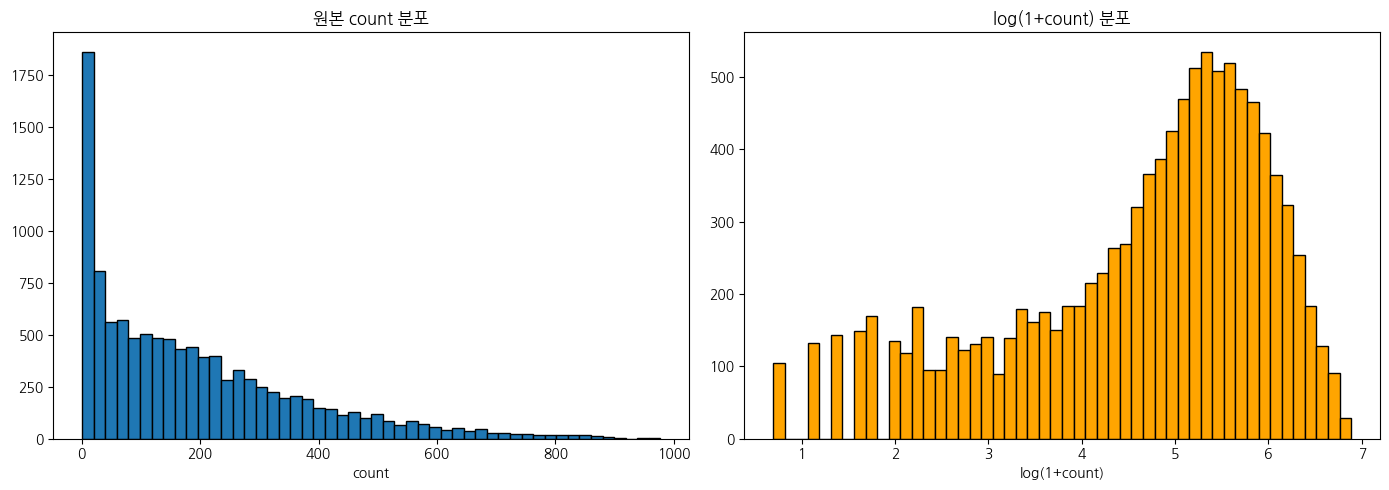

원본 왜도(Skewness): 1.2421
변환 후 왜도(Skewness): -0.8514


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_improved, bins=50, edgecolor='black')
axes[0].set_title('원본 count 분포')
axes[0].set_xlabel('count')

y_log = np.log1p(y_improved)
axes[1].hist(y_log, bins=50, edgecolor='black', color='orange')
axes[1].set_title('log(1+count) 분포')
axes[1].set_xlabel('log(1+count)')

plt.tight_layout()
plt.show()

print(f"원본 왜도(Skewness): {y_improved.skew():.4f}")
print(f"변환 후 왜도(Skewness): {y_log.skew():.4f}")

## 7-4. 개선된 모델 학습

CatBoost 모델을 적용합니다. CatBoost는 범주형 변수를 자동으로 처리할 수 있어 이 데이터에 적합합니다.

In [20]:
from catboost import CatBoostRegressor

# 학습/검증 분리
X_train_i, X_val_i, y_train_i, y_val_i = train_test_split(
    X_improved, y_log, test_size=0.2, random_state=10
)

# 범주형 변수 인덱스 지정
cat_features = [i for i, col in enumerate(X_improved.columns)
                if X_improved[col].dtype.name == 'category']

# CatBoost 모델 학습
cat_model = CatBoostRegressor(
    iterations=700,
    learning_rate=0.05,
    depth=8,
    random_seed=42,
    verbose=200,
    cat_features=cat_features
)

cat_model.fit(X_train_i, y_train_i, eval_set=(X_val_i, y_val_i))

0:	learn: 1.3574395	test: 1.4018616	best: 1.4018616 (0)	total: 16.3ms	remaining: 11.4s
200:	learn: 0.2622256	test: 0.2964035	best: 0.2964035 (200)	total: 1.29s	remaining: 3.21s
400:	learn: 0.2248629	test: 0.2834767	best: 0.2834767 (400)	total: 2.92s	remaining: 2.18s
600:	learn: 0.2012123	test: 0.2799855	best: 0.2799855 (600)	total: 3.5s	remaining: 576ms
699:	learn: 0.1920769	test: 0.2796229	best: 0.2795143 (683)	total: 3.81s	remaining: 0us

bestTest = 0.2795142711
bestIteration = 683

Shrink model to first 684 iterations.


CatBoostRegressor(cat_features=[], depth=8, iterations=700, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=200)

---
# Step 8. 2차 평가 (개선 모델)

개선된 모델의 Train/Test 성능과 오차 크기를 확인합니다.

In [21]:
pred_val_i_log = cat_model.predict(X_val_i)
pred_val_i = np.maximum(0, np.expm1(pred_val_i_log))
y_val_i_orig = np.expm1(y_val_i)

train_score_i = round(r2_score(y_train_i, cat_model.predict(X_train_i)), 4)
test_score_i = round(r2_score(y_val_i, pred_val_i_log), 4)
rmsle_i = round(np.sqrt(mean_squared_log_error(y_val_i_orig, pred_val_i)), 4)

print("[ 2차 평가 - 개선 CatBoost ]")
print(f"  Train Score  : {train_score_i}")
print(f"  Test Score   : {test_score_i}")
print(f"  RMSLE        : {rmsle_i}")

[ 2차 평가 - 개선 CatBoost ]
  Train Score  : 0.9812
  Test Score   : 0.9631
  RMSLE        : 0.2795


---
# Step 9. 1차 vs 2차 비교

두 모델의 성능을 나란히 비교하여 개선 여부를 확인합니다.

In [22]:
comparison = pd.DataFrame({
    '베이스라인 (RF)': [train_score_b, test_score_b, rmsle_b],
    '개선 모델 (CatBoost)': [train_score_i, test_score_i, rmsle_i],
}, index=['Train Score', 'Test Score', 'RMSLE'])

print("[ 최종 비교 ]")
print(comparison.to_string())
print()
print(f"RMSLE 개선율: {(rmsle_b - rmsle_i) / rmsle_b * 100:.1f}% 감소")

[ 최종 비교 ]
             베이스라인 (RF)  개선 모델 (CatBoost)
Train Score      0.9901            0.9812
Test Score       0.9395            0.9631
RMSLE            0.3632            0.2795

RMSLE 개선율: 23.0% 감소


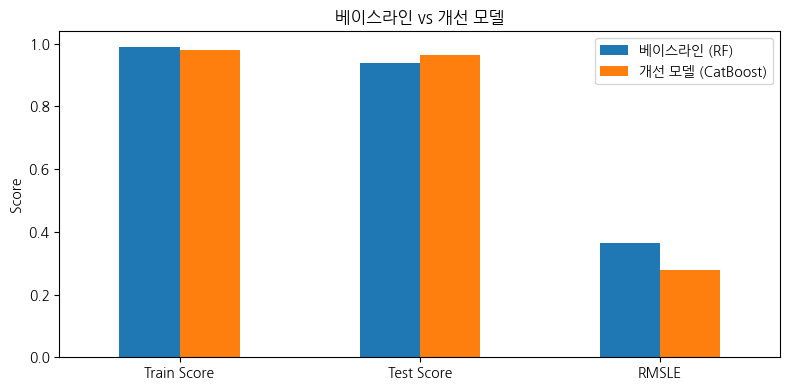

In [23]:
comparison.plot(kind='bar', figsize=(8, 4), rot=0)
plt.title('베이스라인 vs 개선 모델')
plt.ylabel('Score')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

---
# 결론

## 1. 개선 사항 요약

| 개선 항목 | 설명 |
|----------|------|
| 피쳐 엔지니어링 | day_of_week, mean_count_by_hour, daytype, mc_daytype_hour 추가 |
| 변수 선택 | day, month, atemp 제거 (불필요/중복 변수) |
| 타겟 변환 | log(1+count)로 양의 편향 해소 |
| 모델 변경 | RandomForest → CatBoost (범주형 변수 자동 처리) |

## 2. CatBoost가 RandomForest보다 우수한 성능을 보인 이유

1. **범주형 변수의 최적화 처리**:
   *   자전거 데이터에는 계절(season), 날씨(weather), 요일 등 중요한 범주형 변수가 많습니다.
   *   RandomForest는 이를 수치로 변환하여 처리하는 과정에서 정보 손실이 발생할 수 있지만, CatBoost는 내부적으로 **Ordered Target Statistics**를 사용하여 범주형 변수를 효율적으로 처리하므로 데이터의 특성을 더 잘 보존합니다.

2. **비대칭 트리 vs 대칭 트리 (Symmetric Trees)**:
   *   CatBoost는 **Symmetric Tree(대칭 트리)** 구조를 사용합니다. 이는 모든 노드에서 동일한 분할 조건을 사용하여 모델을 단순화하고, 예측 속도를 높이며, **과적합(Overfitting)을 강력하게 억제**하는 효과가 있습니다.

3. **부스팅(Boosting) 알고리즘의 정교함**:
   *   RandomForest는 여러 트리를 독립적으로 학습시켜 평균을 내는 'Bagging' 방식인 반면, CatBoost는 이전 트리의 오차를 다음 트리가 학습하며 보완하는 'Boosting' 방식입니다.
   *   특히 CatBoost는 기존 부스팅 모델의 고질적 문제인 **'Target Leakage'를 방지하는 알고리즘**이 적용되어 있어, 적은 데이터에서도 훨씬 정교한 예측이 가능합니다.

4. **하이퍼파라미터 민감도**:
   *   RandomForest는 파라미터 튜닝 없이도 준수한 성능을 내지만 한계가 명확합니다. 반면 CatBoost는 기본 설정 자체가 매우 강력하게 설계되어 있어, 전처리(Log 변환 등)와 결합했을 때 훨씬 높은 일반화 성능을 보일 수 있습니다.

## 3. 핵심 교훈
1. **피쳐 엔지니어링**이 모델 성능 향상에 가장 큰 영향을 미침
2. **타겟 변환**(log transform)이 편향된 분포에서 효과적
3. **불필요한 변수 제거**가 오히려 성능을 향상시킬 수 있음
4. **모델 선택**도 중요하지만, 데이터 전처리가 선행되어야 함

In [ ]:
# === Refactored End-to-End Pipeline (Feature Engineering + Log Target + Preprocessing) ===
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_log_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1) Raw data load
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# 2) Data cleaning (drop unusable ID-like columns if mostly missing)
for col in ['repo_id', 'id', 'identifier']:
    if col in train_df.columns and train_df[col].isnull().mean() > 0:
        train_df = train_df.drop(columns=[col])
    if col in test_df.columns and test_df[col].isnull().mean() > 0:
        test_df = test_df.drop(columns=[col])

# Basic null handling
train_df = train_df.dropna(subset=['count'])
train_df = train_df.fillna(train_df.median(numeric_only=True))
test_df = test_df.fillna(test_df.median(numeric_only=True))

# 3) Feature engineering
for df in [train_df, test_df]:
    df['datetime'] = pd.to_datetime(df['datetime'])
    df['hour'] = df['datetime'].dt.hour
    df['is_weekend'] = (df['datetime'].dt.dayofweek >= 5).astype(int)

    # day_type: morning_rush (7-9), evening_rush (17-19), else normal
    df['day_type'] = 'normal'
    df.loc[df['hour'].between(7, 9), 'day_type'] = 'morning_rush'
    df.loc[df['hour'].between(17, 19), 'day_type'] = 'evening_rush'

    # weather feature
    df['temp_diff'] = df['atemp'] - df['temp']

# 4) Select features and target
feature_cols = [
    'season', 'weather', 'day_type',
    'temp', 'atemp', 'humidity', 'windspeed', 'temp_diff', 'is_weekend'
]

X = train_df[feature_cols].copy()
y = train_df['count'].copy()
X_test_final = test_df[feature_cols].copy()

# 5) Target transform (log1p)
y_log = np.log1p(y)

X_train, X_val, y_train_log, y_val_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# 6) Preprocessing pipeline
numeric_features = ['temp', 'atemp', 'humidity', 'windspeed', 'temp_diff', 'is_weekend']
categorical_features = ['season', 'weather', 'day_type']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

pipe = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ]
)

# 7) Train
pipe.fit(X_train, y_train_log)

# 8) Predict (inverse transform with expm1)
val_pred_log = pipe.predict(X_val)
val_pred = np.maximum(0, np.expm1(val_pred_log))
y_val = np.expm1(y_val_log)

# 9) Validation metrics
r2 = r2_score(y_val, val_pred)
rmsle = np.sqrt(mean_squared_log_error(y_val, np.maximum(0, val_pred)))

print(f'Refactored Pipeline R2: {r2:.4f}')
print(f'Refactored Pipeline RMSLE: {rmsle:.4f}')

# 10) Test prediction ready for submission
test_pred_log = pipe.predict(X_test_final)
test_pred_count = np.maximum(0, np.expm1(test_pred_log))

submission_refactored = pd.DataFrame({
    'datetime': test_df['datetime'].astype(str),
    'count': test_pred_count
})
submission_refactored.head()